# Final Project: Geospatial Big Data Analysis

**submitted by:** Eliya Levin, 318163748

---

This program analyzes the following question upon a global dataset of power plants:

<div align="center">
  <i>How does the usage of renewable fuels for electricty production affect the level of development and power generation of countries?</i> 
</div>

Analysis and interpretation of results can be found in the adjoined `.docx` file named `Final assignment - project summary`.

---

**Data Sources:**
* `global_power_plant_database.csv` - Main analyzed dataset, extracted from the course Moodle page.
* `API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv` - GDP level data for each country, extracted from the [world bank data](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD) (Last update - 13/07/2026).
* `Continents.shp` - Continent boundary shapefile, extracted from [Figshare website](https://figshare.com/articles/dataset/Continent_Polygons/12555170?file=23392280).

---

## Setup

### Libraries

In order to run program, ensure a correct code environment is set. For further information please refer to the adjoined `environment.yaml` file which lists all required dependencies.

In [37]:
# General
import os

# Data handling
import numpy as np
import pandas as pd
import geopandas as gpd
import json

# Plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Geospatial statistics
from libpysal.weights import KNN, lag_spatial
from libpysal import cg
from esda.moran import Moran, Moran_Local

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Environment
The program can be run on different folders, however it assumes a `data` folder exists in the same directory with all relevant data and an `outputs` folder to save all outputs created during the analysis. For cloned repositories from Github, no additional folder creation is required.

In [38]:
current_dir = os.getcwd() # directory path of the notebook
input_path = os.path.join(current_dir, r'data') # path to the input data folder
output_path = os.path.join(current_dir, r'outputs') # path to the output folder

## EDA: Exploratory Data Analysis

### Initial General Analysis & Cleaning

In [39]:
# Upload power plant csv file: Notice it's not a geographic layer yet
power_plants = pd.read_csv(input_path + r'\global_power_plant_database.csv')

In [40]:
# Inspect data types, columns and null-count
power_plants.info()

<class 'pandas.DataFrame'>
RangeIndex: 25648 entries, 0 to 25647
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   25648 non-null  str    
 1   country_long              25648 non-null  str    
 2   name                      25628 non-null  str    
 3   gppd_idnr                 25648 non-null  str    
 4   capacity_mw               25648 non-null  float64
 5   latitude                  25648 non-null  float64
 6   longitude                 25648 non-null  float64
 7   fuel1                     25648 non-null  str    
 8   fuel2                     1670 non-null   str    
 9   fuel3                     295 non-null    str    
 10  fuel4                     107 non-null    str    
 11  commissioning_year        13926 non-null  float64
 12  owner                     17148 non-null  str    
 13  source                    25648 non-null  str    
 14  url              

In [41]:
# Remove irrelevant columns for analysis
power_plants.drop(columns=['name', 'gppd_idnr', 'owner', 'source', 'url', 'geolocation_source'], inplace=True)

In [42]:
# Inspect primary fuel and remove non-fuel entries
print(power_plants['fuel1'].unique())

power_plants = power_plants[~power_plants['fuel1'].isin(['Cogeneration', 'Storage'])] # Both entries are technology - not fuel

<StringArray>
[         'Hydro',            'Gas',          'Other',            'Oil',
           'Wind',        'Nuclear',           'Coal',          'Solar',
          'Waste',        'Biomass', 'Wave and Tidal',     'Geothermal',
   'Cogeneration',        'Storage',        'Petcoke']
Length: 15, dtype: str


In [43]:
# Classify each plant's primary fuel usage
renewable_fuels = ['Hydro', 'Solar', 'Wind', 'Biomass', 'Wave and Tidal', 'Geothermal']

power_plants['is_renewable'] = (
    power_plants['fuel1']
    .isin(renewable_fuels)  # Verify if entry is part of the renewable fuel list values
    .astype(int)
)

In [44]:
# Merge GDP values from World bank data (13/07/2026)

# Upload GDP csv file
# World bank data has metadata rows at the start, so we add a skiprows argument to avoid errors
gdp = pd.read_csv(input_path + r'\API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv', skiprows=4)

# Filter only relevant columns
gdp = gdp[['Country Code', '2013', '2014', '2015', '2016', '2017']]

# Update column names
gdp.rename(columns={
    'Country Code' : 'country',
    '2013' : 'GDP_2013',
    '2014' : 'GDP_2014',
    '2015' : 'GDP_2015',
    '2016' : 'GDP_2016',
    '2017' : 'GDP_2017',
}, inplace=True)

# Merge with power plant DataFrame
power_plants = power_plants.merge(gdp, how='left', on='country')

# Ensure correct merge
power_plants.head(n=10)

,country,country_long,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,fuel4,commissioning_year,...,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh,is_renewable,GDP_2013,GDP_2014,GDP_2015,GDP_2016,GDP_2017
0,AFG,Afghanistan,33.00,32.3220,65.1190,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
1,AFG,Afghanistan,66.00,34.5560,69.4787,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
2,AFG,Afghanistan,100.00,34.6410,69.7170,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
3,AFG,Afghanistan,11.55,34.4847,70.3633,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
4,AFG,Afghanistan,42.00,34.5638,69.1134,Gas,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
5,AFG,Afghanistan,6.00,35.9416,68.7100,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
6,AFG,Afghanistan,22.00,34.5865,69.7757,Hydro,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10
7,ALB,Albania,27.00,39.9116,20.1047,Hydro,NaN,NaN,NaN,1965.0,...,NaN,NaN,NaN,89.132075,1,1.279699e+10,1.329632e+10,1.147017e+10,1.198867e+10,1.325827e+10
8,ALB,Albania,500.00,42.2514,20.0431,Hydro,NaN,NaN,NaN,1978.0,...,NaN,NaN,NaN,1650.593990,1,1.279699e+10,1.329632e+10,1.147017e+10,1.198867e+10,1.325827e+10
9,ALB,Albania,600.00,42.1033,19.8224,Hydro,NaN,NaN,NaN,1985.0,...,NaN,NaN,NaN,1980.712788,1,1.279699e+10,1.329632e+10,1.147017e+10,1.198867e+10,1.325827e+10


In [45]:
# Remove rows with missing GDP values - as this would be our response variable
# Dynamic creation of GDP columns ordered by year
gdp_cols = sorted([col for col in power_plants.columns if col.startswith('GDP_')]) 

# Remove rows
power_plants = power_plants.dropna(subset=gdp_cols)

# Print no. rows removed
after = len(power_plants) # current shape
print(f"Removed {25648 - after:,} rows") # original shape - 25648 rows

# Re-check null count for data
print()
power_plants.info()

Removed 165 rows

<class 'pandas.DataFrame'>
Index: 25483 entries, 0 to 25569
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   25483 non-null  str    
 1   country_long              25483 non-null  str    
 2   capacity_mw               25483 non-null  float64
 3   latitude                  25483 non-null  float64
 4   longitude                 25483 non-null  float64
 5   fuel1                     25483 non-null  str    
 6   fuel2                     1661 non-null   str    
 7   fuel3                     292 non-null    str    
 8   fuel4                     107 non-null    str    
 9   commissioning_year        13813 non-null  float64
 10  year_of_capacity_data     15984 non-null  float64
 11  generation_gwh_2013       56 non-null     float64
 12  generation_gwh_2014       55 non-null     float64
 13  generation_gwh_2015       536 non-null    float64
 14  gene

### Numerical Column Exploratory Analysis

In [46]:
# Describe base statistics for numeric columns
power_plants.describe().T

,count,mean,std,min,25%,50%,75%,max
capacity_mw,25483.0,1.567057e+02,4.513873e+02,1.000000e+00,4.000000e+00,1.468000e+01,8.000000e+01,8.868000e+03
latitude,25483.0,3.186591e+01,2.517581e+01,-5.378620e+01,2.837535e+01,4.078250e+01,4.824125e+01,7.129200e+01
longitude,25483.0,-2.756928e+01,6.690267e+01,-1.717124e+02,-8.180760e+01,-3.486690e+01,8.237700e+00,1.774833e+02
commissioning_year,13813.0,1.993999e+03,2.396793e+01,1.896000e+03,1.984000e+03,2.003000e+03,2.012000e+03,2.018000e+03
year_of_capacity_data,15984.0,2.016036e+03,1.264392e+00,2.000000e+03,2.016000e+03,2.016000e+03,2.016000e+03,2.018000e+03
generation_gwh_2013,56.0,2.518016e+03,7.274323e+03,1.000000e+01,1.393150e+02,4.390000e+02,1.356750e+03,5.083400e+04
generation_gwh_2014,55.0,4.033036e+03,4.743669e+03,7.000000e+00,6.375000e+02,2.196000e+03,5.818500e+03,2.161500e+04
generation_gwh_2015,536.0,1.411244e+03,3.719310e+03,0.000000e+00,2.615525e+01,2.710000e+02,1.342547e+03,5.954686e+04
generation_gwh_2016,8582.0,6.073364e+02,2.087480e+03,-7.686200e+02,3.371500e+00,2.389950e+01,2.210938e+02,3.237748e+04
estimated_generation_gwh,24814.0,6.975611e+02,2.449066e+03,0.000000e+00,6.743834e+00,3.467582e+01,2.539436e+02,4.714049e+04


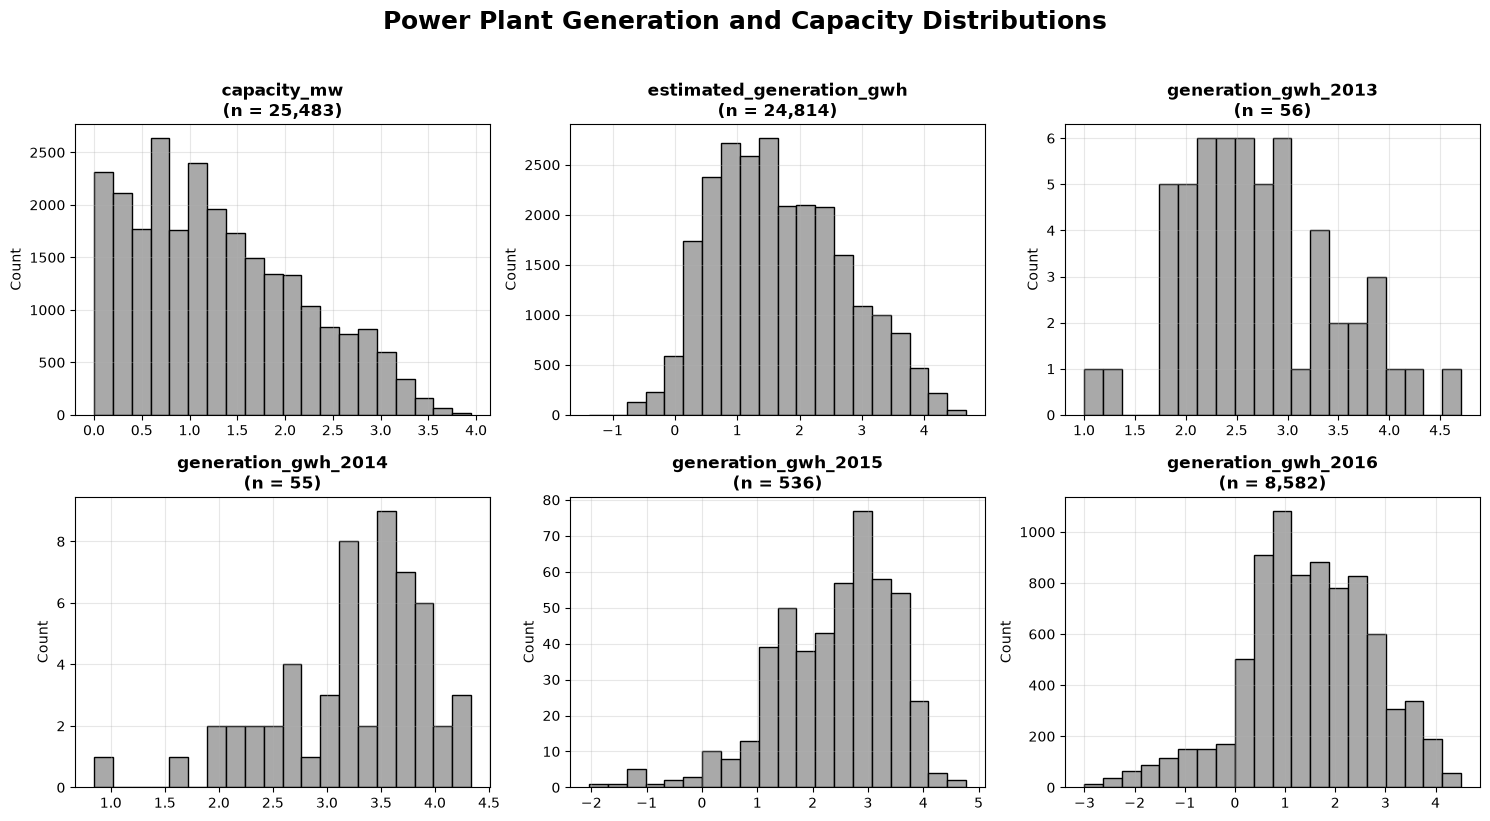

In [47]:
# Plot original numeric columns (capacity and electrical output) distributions
# List all columns distributions in requested plot order
plot_cols = ['capacity_mw', 'estimated_generation_gwh', 'generation_gwh_2013',
             'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016']

# Define figure settings
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten() # Flatten axes list for loop ploting

# Plot all numeric variables distributions
for ax, col in zip(axes, plot_cols):

    data = power_plants[col].dropna() # Remove all nulls for plot
    log_data = np.log10(data[data > 0]) # Log transform data for better interpretability and magnitude comparisson

    # Transformed variable histogram
    ax.hist(
        log_data,
        bins=20,
        edgecolor='black',
        color='darkgrey'
    )

    # Design sub-plot
    ax.set_title(f'{col}\n(n = {len(data):,})', fontweight='bold') # Include feature number (non-null values in column)
    ax.set_ylabel('Count')
    ax.set_xlabel('')
    ax.grid(alpha=0.3)

# Add general plot title
fig.suptitle(
    'Power Plant Generation and Capacity Distributions',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant generation and capacity distributions.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

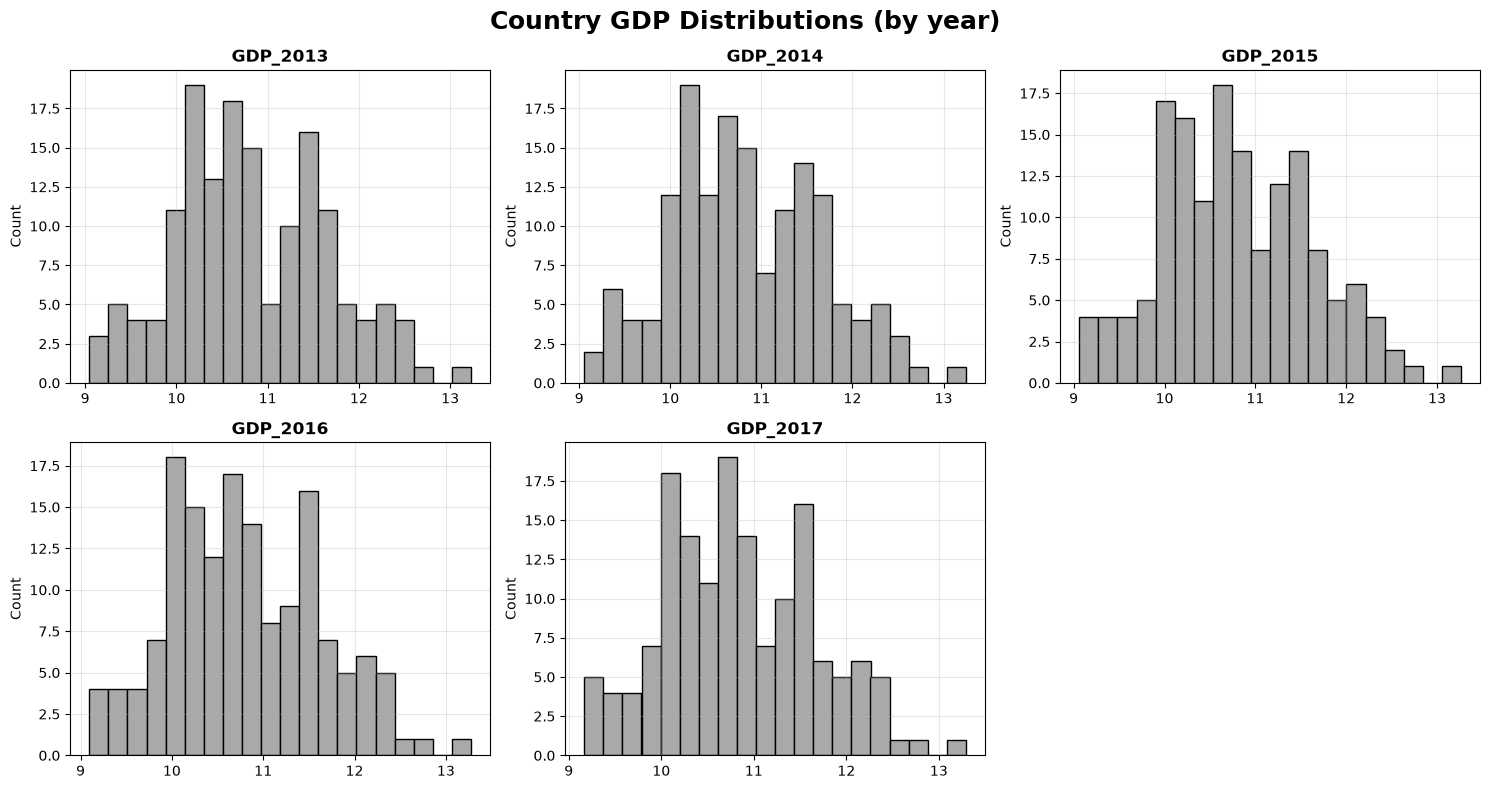

In [48]:
# Plot GDP distributions
# Grid size
n_cols = 3
n_rows = int(np.ceil(len(gdp_cols) / n_cols)) # Dynamic rows based on facet number

# Define figure settings
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows) # Dynamic figure size based on facet number
)
axes = axes.flatten()

# Plot all GDP distributions
for ax, col in zip(axes, gdp_cols):

    data = power_plants[col].dropna().drop_duplicates() # Remove missing values and duplicates (if exist)

    # Log-transform GDP values
    log_data = np.log10(data[data > 0]) # GDP tend to be highly skewed, therefore we apply log transform

    # Plot histogram
    ax.hist(
        log_data,
        bins=20,
        edgecolor='black',
        color='darkgrey'
    )

    # Design sub-plot labels
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel('')
    ax.grid(alpha=0.3)

# Remove unused axes
for ax in axes[len(gdp_cols):]:
    fig.delaxes(ax)

# Add general title
fig.suptitle(
    'Country GDP Distributions (by year)',
    fontsize=18,
    fontweight='bold'
)

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Country GDP distributions.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

### Categorical Column Exploratory Analysis

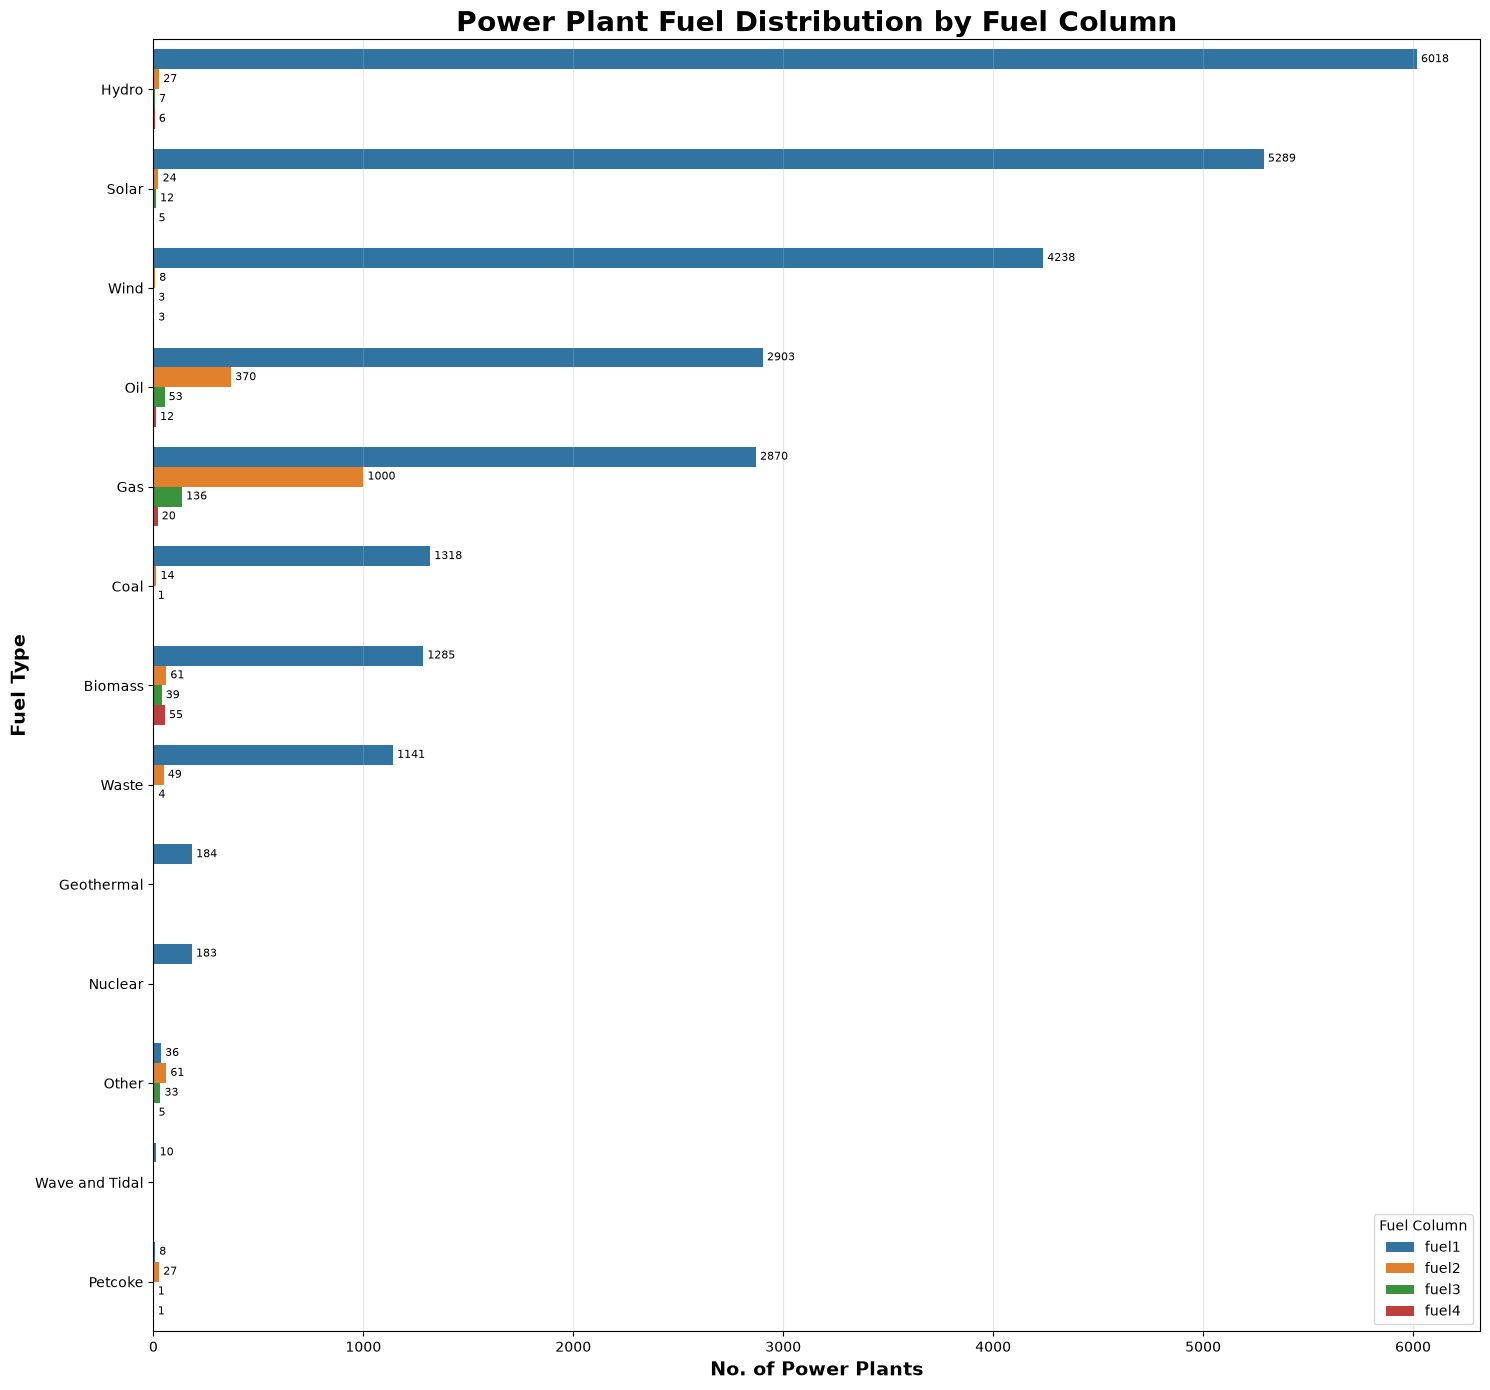

In [49]:
# Plot fuel types' (primary and others) distributions
# Define relevant plot columns
fuel_cols = ['fuel1', 'fuel2', 'fuel3', 'fuel4']

# Convert wide to long format for simpler ploting
fuel_long = (
    power_plants[fuel_cols]
    .melt(var_name='Fuel Column', value_name='Fuel Type')
    .dropna()
)

# Count values
fuel_counts = (
    fuel_long
    .groupby(['Fuel Column', 'Fuel Type']) # Count instances for each fuel type in each column
    .size()
    .reset_index(name='Count')
)

# Define order based on fuel1 - primary fuel source, most highly documented
fuel_order = (
    power_plants['fuel1']
    .value_counts()
    .index
)

# Define figure size
plt.figure(figsize=(15, 14))

# Plot all categories in descending order (based on fuel1)
ax = sns.barplot(
    data=fuel_counts,
    y='Fuel Type',
    x='Count',
    hue='Fuel Column', # Ensure different color for every column
    order=fuel_order
)

# Add labels - actual counts for interpretability
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=8
    )

# Add title and axis labels
ax.set_title('Power Plant Fuel Distribution by Fuel Column', fontsize=20, fontweight='bold')
ax.set_xlabel('No. of Power Plants', fontsize=14, fontweight='bold')
ax.set_ylabel('Fuel Type', fontsize=14, fontweight='bold')

# Add grid
ax.grid(axis='x', alpha=0.3)

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant fuel distributions.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

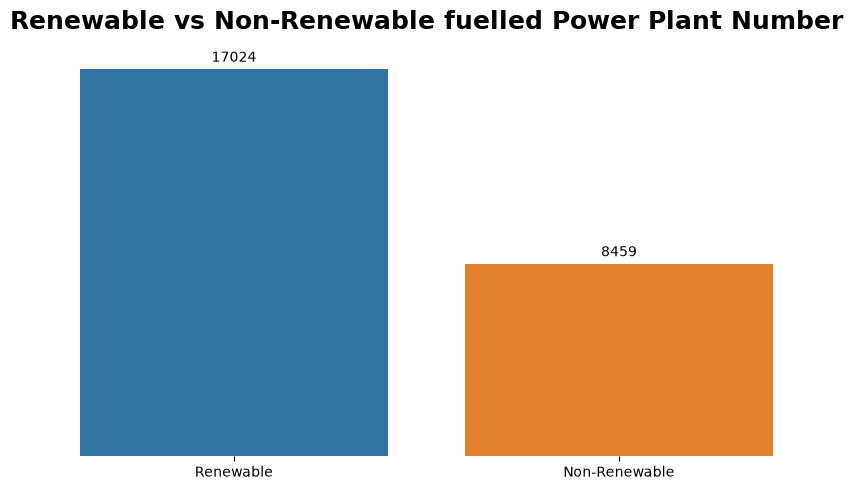

In [50]:
# Plot renewable vs. non-renewable fuel source shares
# Arrange data for plot
renewable_counts = (
    power_plants['is_renewable']
    .map({0: 'Non-Renewable', 1: 'Renewable'}) # Map binary values to labels using dictionary
    .value_counts()
    .reset_index()
)

# Define figure size
plt.figure(figsize=(8, 5))

# Plot using bar chart
ax = sns.barplot(
    data=renewable_counts,
    x='is_renewable',
    y='count',
    hue='is_renewable',
    legend=False
)

# Add values above bars for interpretability
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=10
    )

# Add title
ax.set_title('Renewable vs Non-Renewable fuelled Power Plant Number', fontsize=18, fontweight='bold', pad=15)

# Remove frame, axis labels and ticks
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant renewable fuel share.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

### Temporal Distributions - Comissioning Year

In [51]:
# Arrange data for ploting
# Yearly data
year_counts = (
    power_plants['commissioning_year']
    .dropna()                           # Remove missing years
    .astype(int)                        # Ensure yearly format - integer and not float
    .value_counts()                     # Bin data
    .sort_index()                       # Sort in ascending year order
    .reset_index()
)

year_counts.columns = ['Year', 'Count'] # Define column names
years = year_counts['Year'] # Extract all years

# Decade data - aggregate year count by decade
decade_counts = (
    year_counts
    .assign(Decade=(year_counts['Year'] // 10) * 10) # Assign each year to it's decade
    .groupby('Decade', as_index=False)['Count']      # Group years by decade
    .sum()
)

decade_counts.columns = ['Decade', 'Count'] # Define column names

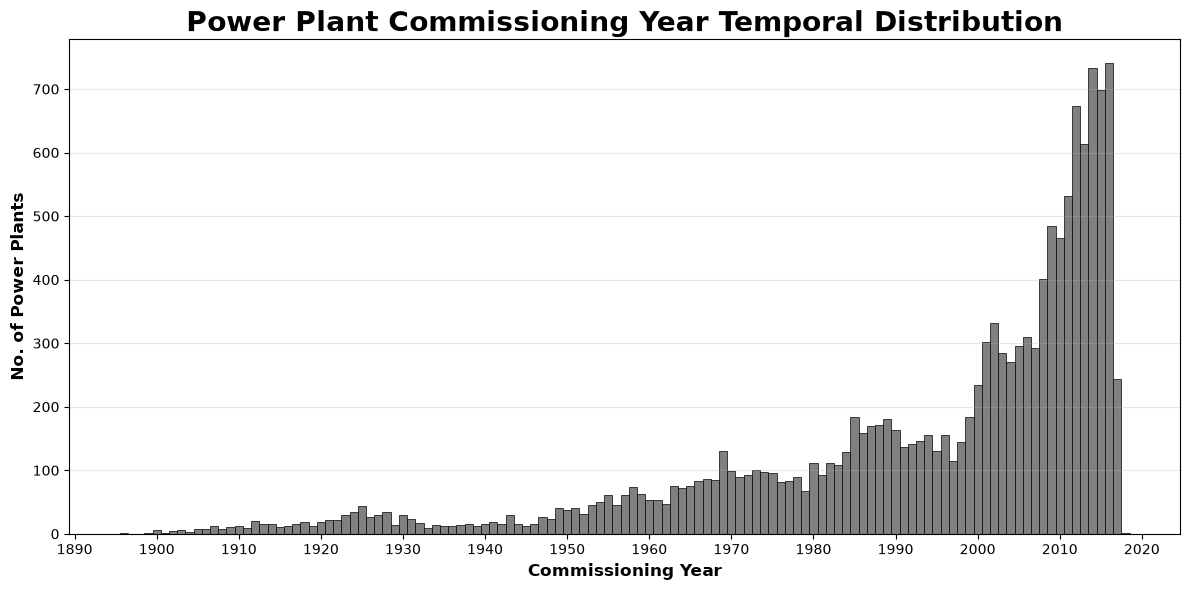

In [52]:
# Plot Temporal distribution: by year
# Define figure size
fig, ax = plt.subplots(figsize=(12, 6))

# Plot distribution
ax.bar(
    year_counts['Year'],
    year_counts['Count'],
    width=1,               # Each bar represents one year
    color='grey',
    edgecolor='black',
    linewidth=0.5
)

# Set ticks every decade for better interpretability
ax.set_xticks(
    np.arange(
        years.min() - years.min() % 10,
        years.max() + 10,
        10
    )
)

# Add title and axis labels
ax.set_title('Power Plant Commissioning Year Temporal Distribution', fontsize=20, fontweight='bold')
ax.set_xlabel('Commissioning Year', fontsize=12, fontweight='bold')
ax.set_ylabel('No. of Power Plants', fontsize=12, fontweight='bold')

# Design plot area
ax.tick_params(axis='x') # Remove irrelevant ticks
ax.grid(axis='y', alpha=0.3) # Add grid lines on y axis

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant commissioning year temporal distribution.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

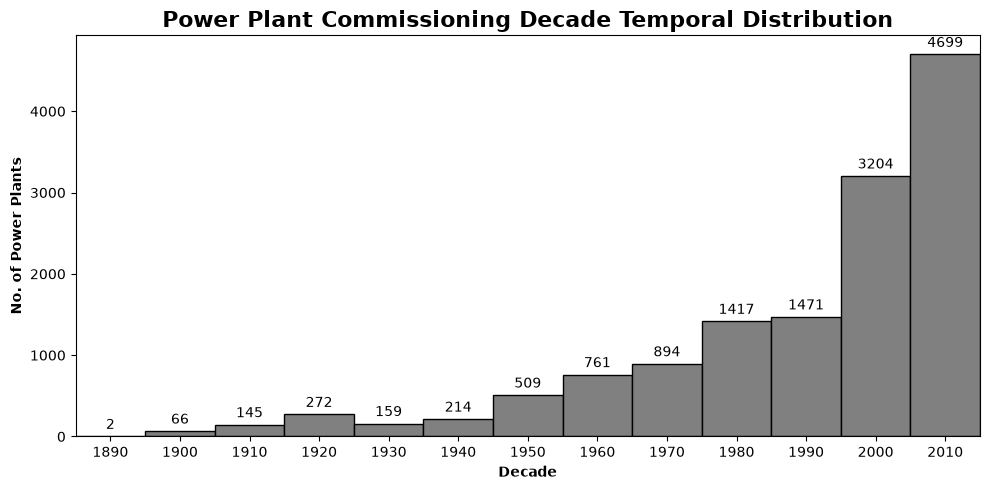

In [53]:
# Plot Temporal distribution: by decade
# Define figure size
plt.figure(figsize=(10, 5))

# Plot distribution
ax = sns.barplot(
    data=decade_counts,
    x='Decade',
    y='Count',
    width=1,     # Remove spaces between columns
    color='grey',
    edgecolor='black',
    linewidth=1
)

# Add counts above each bar
ax.bar_label(ax.containers[0], fmt='%d', padding=3)

# Add title and axis labels
ax.set_title('Power Plant Commissioning Decade Temporal Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Decade', fontweight='bold')
ax.set_ylabel('No. of Power Plants', fontweight='bold')

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant commissioning decade temporal distribution.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

### Spatial Distribution

In [54]:
# Convert to GeoDataFrame using longitude and latitude columns.
# Note: CRS is defined as EPSG 4326 (geographical world Datum WGS84), as it is a global dataset.
power_plants = gpd.GeoDataFrame(
    power_plants,
    geometry=gpd.points_from_xy(
        power_plants.longitude,
        power_plants.latitude
    ),
    crs="EPSG:4326"
)

In [55]:
continents = gpd.read_file(input_path + r'\Continents.shp') # Upload continent boundaries layer for spatial distribution plot
continents.to_crs(epsg=4326) if continents.crs != '4326' else None # Ensure CRS compatibility with power plant layer

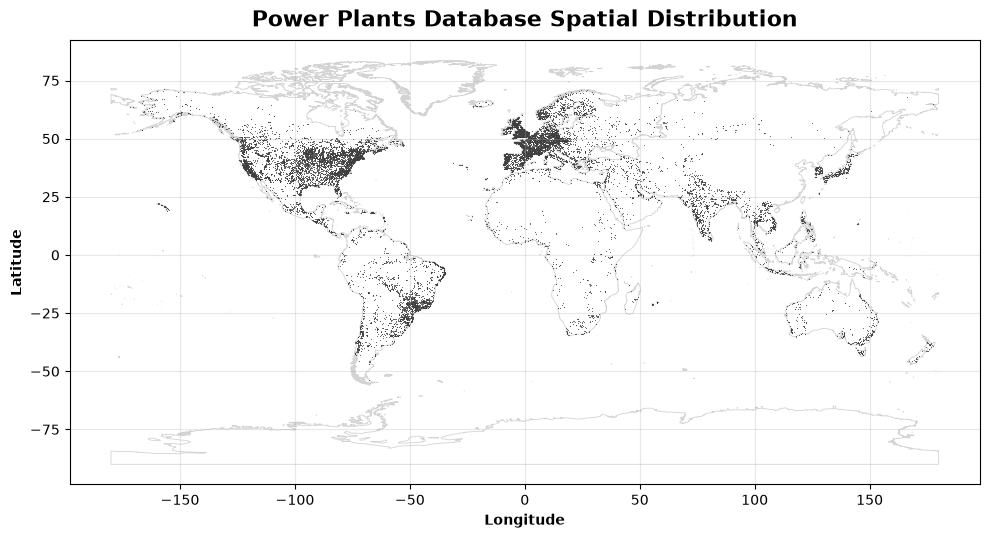

In [56]:
# Plot spatial distribution on map
# Define figure size
fig, ax = plt.subplots(figsize=(10, 6)) 

# Plot continent boundaries as basemap
continents.plot(
    ax=ax,
    color='white',
    edgecolor='lightgrey',
    linewidth=0.6
)

# Plot all power plant locations
power_plants.plot(
    ax=ax,
    markersize=0.4,
    color='black',
    edgecolor='grey',
    linewidth=0.1
)

# Add title and axis labels
ax.set_title('Power Plants Database Spatial Distribution', fontsize=16, fontweight='bold', pad=10)
ax.set_xlabel('Longitude', fontweight='bold')
ax.set_ylabel('Latitude', fontweight='bold')

# Add geographic gridlines
ax.grid(True, alpha=0.3) 

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant spatial distribution.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

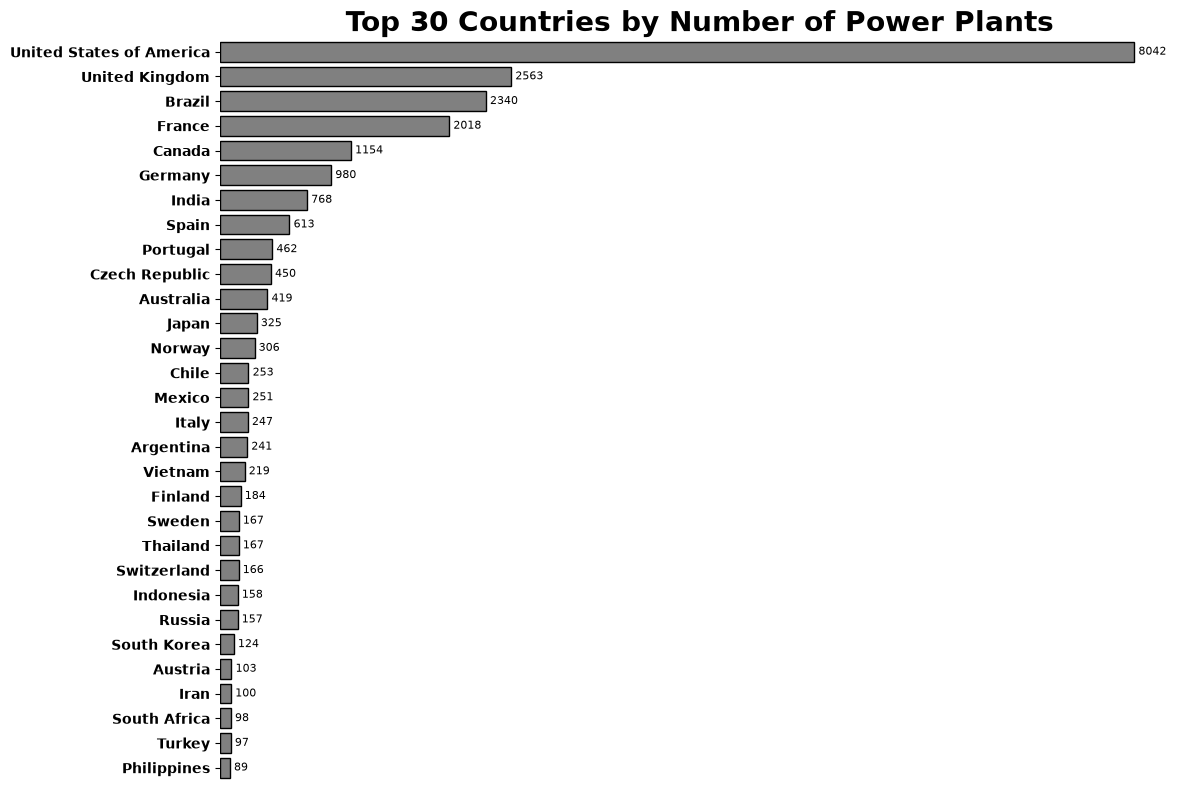

In [57]:
# Analysis by country
# Arrange data
country_counts = (
    power_plants['country_long']
    .value_counts()                 # Count plants per country
    .head(30)                       # Maintain only top 30 countries
    .reset_index()
)
country_counts.columns = ['Country', 'Count'] # Define column names

# Define figure size
plt.figure(figsize=(12, 8))

# Plot top 30 countries in descending order
ax = sns.barplot(
    data=country_counts,
    y='Country',
    x='Count',
    order=country_counts['Country'],
    color='grey',
    edgecolor='black'
)

# Add labels in each bar for inerpretability
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=8
    )

# Add title
ax.set_title('Top 30 Countries by Number of Power Plants', fontsize=20, fontweight='bold')

# Remove frame, axis labels and ticks
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# Make y-axis labels bold
plt.setp(ax.get_yticklabels(), fontweight='bold')

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Top 30 countries by number of power plants.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

In [58]:
# Analysis of renewable fuelled plants proportion by continent
# Spatial join (using GeoPandas) between continents and power plants
plants_with_continents = gpd.sjoin(
    power_plants,
    continents[['CONTINENT', 'geometry']],
    how='left',
    predicate='within'
)

# Summarize plant numbers by continent
continent_summary = (
    plants_with_continents
    .groupby('CONTINENT')
    .agg(
        total_plants=('country', 'count'),
        renewable_plants=('is_renewable', 'sum')
    )
    .reset_index()
)

# Compute the renewable fuel run plants proportion by continent
continent_summary['renewable_share'] = (continent_summary['renewable_plants'] / continent_summary['total_plants'])

# Sort continents by total number of plants
continent_summary = continent_summary.sort_values(
    'total_plants',
    ascending=False
)

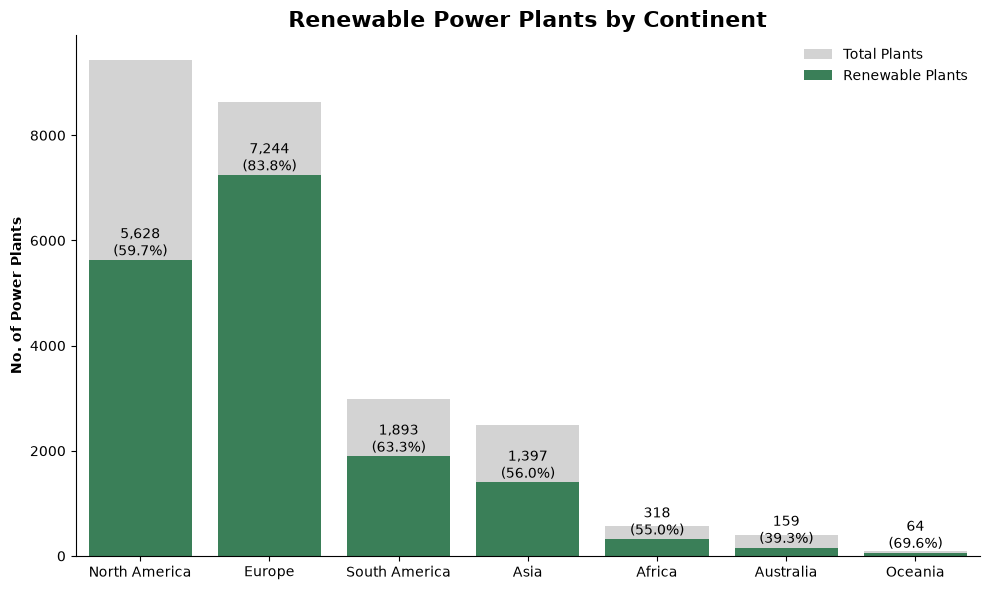

In [59]:
# Plot proportions above total number
# Define figure setup
plt.figure(figsize=(10, 6))

# Total plants background bars
sns.barplot(
    data=continent_summary,
    x='CONTINENT',
    y='total_plants',
    color='lightgrey',
    label='Total Plants'
)

# Renewable plants overlay
sns.barplot(
    data=continent_summary,
    x='CONTINENT',
    y='renewable_plants',
    color='seagreen',
    label='Renewable Plants'
)

# Annotate renewable bars using proportion
for i, row in continent_summary.reset_index(drop=True).iterrows():
    plt.text(
        i,
        row['renewable_plants'],
        f"{row['renewable_plants']:,}\n({row['renewable_share']:.1%})",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Add title and axis labels
plt.xlabel('')
plt.ylabel('No. of Power Plants', fontweight='bold')
plt.title('Renewable Power Plants by Continent', fontsize=16, fontweight='bold')

# Add legend
plt.legend(frameon=False)

# Remove frame for better design
sns.despine()

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Spatial distribution of plants and renewable fuelled pplants by continent.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

## Research Question Analysis

### Epicenter of renewable fuel usage
**Is there an epicenter for renewable fuel usage, and is there some spatial structure?**

In order to answer this question, I'll now test autocorrelation for the binary renewable fuel variable (i.e., how is the usage of renewable fuel correlated with itself along the geographical plane). To do so, I'll first compute a weigths matrix that will define the spatial relationships between power plants (K Nearest Neighbor to account for varrying distances with $k=8$ as a standard baseline for big data files). Afterwards, I'll compute a $Moran's \; I$ Statistic both globally and locally to analyze clustering.

In [60]:
# Create a weights matrix for analysis
# We will define a KNN with k=8 as our basic structure (defines the first order neighbor square)
# Note 1: To avoid stretching and inflation, we maintain the WGS84 Datum and compute distances based on great circles
# Note 2: we use only the computed is_renewable variable based on the primary fuel source for analysis here due to large number of missing values in all other columns.

# Define coordinates as a numpy ndarray for simpler computation
coords = np.column_stack([
    power_plants.geometry.x,
    power_plants.geometry.y
])

# Build weights matrix
w = KNN.from_array(
    coords,
    k=8,
    radius=cg.RADIUS_EARTH_KM # Define usage of kilometers upon great circle radii
)

w.transform = 'r' # Apply rowwise normalization

c:\Users\eliya\anaconda3\envs\geospatial\Lib\site-packages\libpysal\weights\distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 30 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [61]:
# Define relevant column for analysis
moran_col = power_plants['is_renewable']

In [62]:
# Global Moran's I: renewable fuels Autocorrelation

# Calculate Moran's I statistic
moran = Moran(moran_col, w)

# Save results to dictionary
global_moran = {                               
    'Moran_I' : round(moran.I, 4), 
    'p_value' : moran.p_sim
    }

# Save as json to outputs folder
with open(
    os.path.join(output_path, "global_moran_result.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(global_moran, f, indent=4, ensure_ascii=False)

# Present results
print(f'Global Moran\'s I: {global_moran['Moran_I']} (p={global_moran['p_value']})')

Global Moran's I: 0.4511 (p=0.001)


In [63]:
# Local Moran's I: renewable fuels clustering

# Calculate local Moran's I statistic
lisa = Moran_Local(moran_col, w)

# Calculate spatial lag
lag = lag_spatial(w, moran_col)

# Standardize values
z = np.asarray((moran_col - np.mean(moran_col)) / np.std(moran_col, ddof=1)) # Use numpy statistical methods for assignment requirements but ensure pandas compatibility using ddof
z_lag = np.asarray((lag - np.mean(lag)) / np.std(lag, ddof=1)) # Use numpy statistical methods for assignment requirements but ensure pandas compatibility using ddof

# Classification
# Initiate empty list for categories
categories = []

# Classify each power plant's category
for i in range(len(moran_col)):
    if lisa.p_sim[i] < 0.05:
        if z[i] > 0 and z_lag[i] > 0:
            categories.append('High-High')
        elif z[i] < 0 and z_lag[i] < 0:
            categories.append('Low-Low')
        elif z[i] > 0 and z_lag[i] < 0:
            categories.append('High-Low')
        else:
            categories.append('Low-High')
    else:
        categories.append('Not Significant')

# Append results to data
power_plants['LISA'] = categories

# Compute proportions
lisa_summary = (
        power_plants['LISA']
        .value_counts()
        .to_dict()
    )

# Save as json to outputs folder
with open(
    os.path.join(output_path, "local_moran_results.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(lisa_summary, f, indent=4, ensure_ascii=False)

# Present results
print('Local Moran\'s I:')
print("-" * 25)
for cluster, count in lisa_summary.items():
    print(f"{cluster}: {count:,}")

Local Moran's I:
-------------------------
Not Significant: 11,402
High-High: 8,203
Low-Low: 4,088
Low-High: 918
High-Low: 872


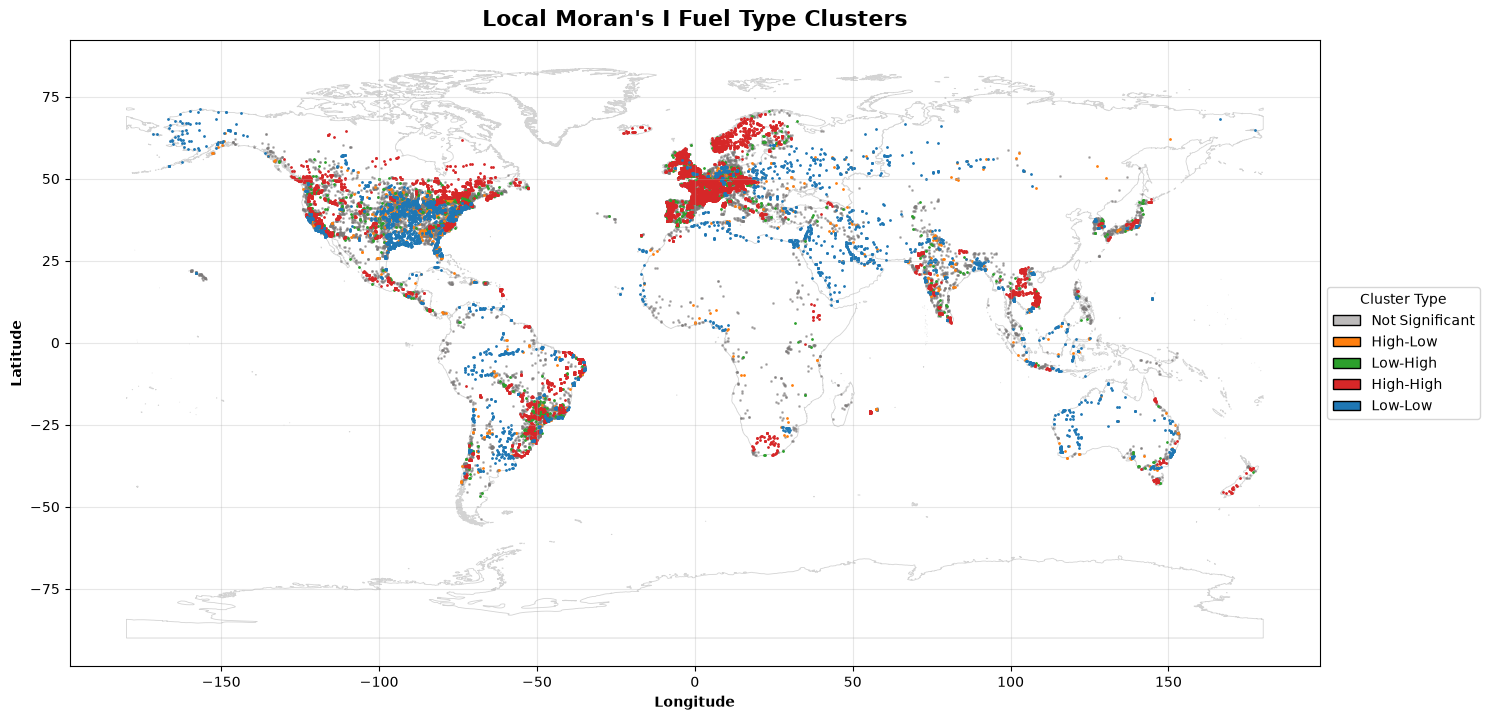

In [64]:
# Plot LISA analysis: clustering of renewable fuels
# Define colors and plot order (to highlight autocorrelated clusters)
lisa_colors = {
    'Not Significant': "#7c797980",
    'High-Low': '#ff7f0e',
    'Low-High': '#2ca02c',
    'High-High': '#d62728',
    'Low-Low': '#1f77b4'
}

# Define figure size
fig, ax = plt.subplots(figsize=(15, 8))

# Initiate empty legend handles
legend_elements = []

# Plot continents as basemap
continents.plot(
    ax=ax,
    color='white',
    edgecolor='lightgrey',
    linewidth=0.6
)

# Plot each LISA category
for category, color in lisa_colors.items():

    subset = power_plants[power_plants['LISA'] == category] # Specific lisa category

    if not subset.empty:
        # Plot
        subset.plot(
            ax=ax,
            color=color, # Color by defined map
            markersize=1
        )

        # Add legend entry
        legend_elements.append(Patch(
            facecolor=color,
            edgecolor='black',
            label=category
            ))

# Add title and axis labels
ax.set_title('Local Moran\'s I Fuel Type Clusters', fontsize=16, fontweight='bold', pad=10)
ax.set_xlabel('Longitude', fontweight='bold')
ax.set_ylabel('Latitude', fontweight='bold')

# Legend formatting
ax.legend(
    handles=legend_elements,
    title='Cluster Type',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

# Add geographic gridlines
ax.grid(True, alpha=0.3)  

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant lisa map.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

### Correlation Analysis

#### Prediction of Missing Plant Actual Capacities (GWh) using Machine Learning

As the plant yearly estimated energy production in GWh (`estimated_generation_gwh`) is a more accurate depiction of plant power capacity, we will use it to check correlation between renewable fuel usage and energy capacity. However, due to the missing values that exist, I'll first interpolate them using a random forest regression that will predict the values based upon other key variables. This will be done including accounting for missing values by implementing imputer pipelines. Random forest was chosen as it is better suited to non-linear data.

In [65]:
# Arrange ML setup

# Explanatory variables: geographic location (defined by lon/lat and not by country), capacity, primary fuel, commissioning year,
#                        capacity data and historical GWh for 2016 (only one with sufficient samples)
features = [
    'longitude',
    'latitude',
    'capacity_mw',
    'fuel1',
    'commissioning_year',
    'year_of_capacity_data',
    'generation_gwh_2016'
]

# Target variable
target = 'estimated_generation_gwh'

# Split known and missing target rows (learning will be done only on known rows)
train_data = power_plants[power_plants[target].notna()].copy()
predict_data = power_plants[power_plants[target].isna()].copy() # These rows will have predicted GWh values

# Arrange variables for model setup
X = train_data[features]
y = train_data[target]

# Train-test split for evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # Keep 20% of data as test set
    random_state=42 # For reproductibility
)

# Define variable types for transformers
categorical_feature = ['fuel1']

numeric_features = [
    'longitude',
    'latitude',
    'capacity_mw',
    'commissioning_year',
    'year_of_capacity_data',
    'generation_gwh_2016'
]


# Preprocessing: dealing with missing values for explanatory variables and encoding categorical features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_feature)
])

In [66]:
# Run model
# Define regression model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])


# Train
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test) # Predict values for train set

rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Compute RMSE
nrmse = rmse / y_test.mean() # Compte normalized RMSE for interpretability
r2 = r2_score(y_test, y_pred) # Compute R^2

# Print results
print(f"RMSE: {rmse:,.2f} GWh")
print(f"Normalized RMSE: {nrmse:.2%}")
print(f"R²: {r2:.3f}")

RMSE: 772.91 GWh
Normalized RMSE: 117.34%
R²: 0.882


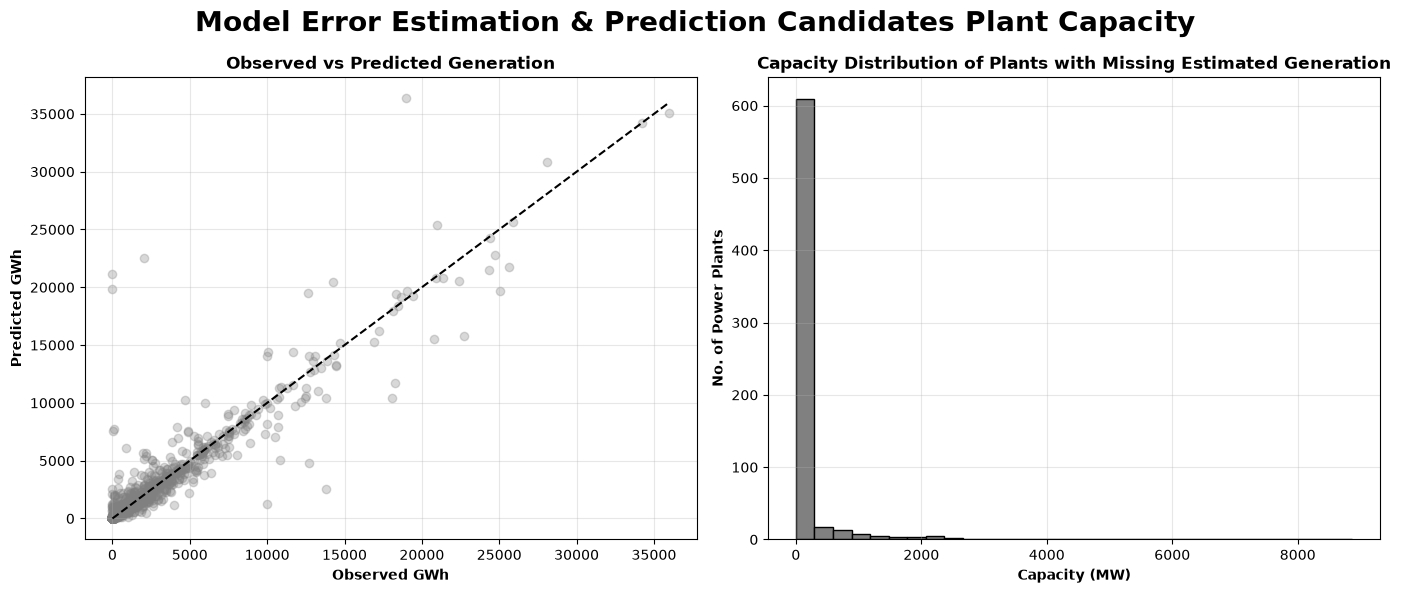

In [67]:
# Present model accuracy by prediction missing values for comparisson
# Define figure setup
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First plot: model errors
# prediction scatter plot
axes[0].scatter(
    y_test,
    y_pred,
    color='grey',
    alpha=0.3
)

# Regression line
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--',
    color='black'
)

# Ax title and axis labels
axes[0].set_xlabel('Observed GWh', fontweight='bold')
axes[0].set_ylabel('Predicted GWh', fontweight='bold')
axes[0].set_title('Observed vs Predicted Generation', fontweight='bold')


# Second plot: Prediction candidates capacity distribution
axes[1].hist(
    predict_data['capacity_mw'].dropna(),
    bins=30,
    edgecolor='black',
    color='grey'
)

# Ax title and axis labels
axes[1].set_xlabel('Capacity (MW)', fontweight='bold')
axes[1].set_ylabel('No. of Power Plants', fontweight='bold')
axes[1].set_title("Capacity Distribution of Plants with Missing Estimated Generation", fontweight='bold')

# General formating
fig.suptitle('Model Error Estimation & Prediction Candidates Plant Capacity', fontweight='bold', fontsize=20)

# Add gridlines
for ax in axes:
    ax.grid(alpha=0.3)

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Power plant prediction evaluation.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()

In [68]:
# Predict missing estimated_generation_gwh using model
missing_predictions = model.predict(
    predict_data[features]
)

# Fill missing values
power_plants.loc[power_plants[target].isna(), target] = missing_predictions

# Print no. of missing values predicted
print(f"Predicted {len(missing_predictions):,} missing values")

Predicted 669 missing values


#### Correlation Analysis: Renewable Fuel Usage vs. GDP / Power Capacity

In [69]:
# Aggregate data by country for analysis
renewable_usage = (
    power_plants
    .groupby(['country', 'country_long']) # Keep both ISO code and country name
    .agg(
        gdp=('GDP_2017', 'first'),                                     # Most updated GDP extracted (closest to historical data in dataset)
        total_est_generation_gwh=('estimated_generation_gwh', 'sum'),  # Sum of all estimated capacity in country
        avg_est_generation_gwh=('estimated_generation_gwh', 'mean'),   # Average estimated plant capacity in country
        total_plants=('country', 'count'),                             # Number of plants
        renewable_plants=('is_renewable', 'sum'))                      # Number of plants run on renewable fuels
    .reset_index()
)

# Calculate renewable fuel run plant proportion
renewable_usage['renewable_plants_prop'] = (
    renewable_usage['renewable_plants'] /
    renewable_usage['total_plants']
)

# Calculate total estimated capacity from renewable fuel run plants by country
renewable_generation = (
    power_plants[power_plants['is_renewable'] == 1] # Filter using binary column
    .groupby('country')
    ['estimated_generation_gwh']
    .sum()
    .reset_index(name='renewable_est_generation_gwh') # Rename against ambiguity
)

# Merge created column to country results
renewable_usage = renewable_usage.merge(
    renewable_generation,
    on='country',
    how='left'
)

# Save results to csv file
renewable_usage.to_csv(os.path.join(output_path, 'aggregated gdp and power capacity by country.csv'), encoding="utf-8")

In [70]:
renewable_usage[
    ['gdp', 'total_plants', 'renewable_plants_prop', 'renewable_est_generation_gwh', 'total_est_generation_gwh']
].corr()

,gdp,total_plants,renewable_plants_prop,renewable_est_generation_gwh,total_est_generation_gwh
gdp,1.000000,0.932216,0.063969,0.763191,0.968539
total_plants,0.932216,1.000000,0.119177,0.801916,0.896043
renewable_plants_prop,0.063969,0.119177,1.000000,0.111223,0.038147
renewable_est_generation_gwh,0.763191,0.801916,0.111223,1.000000,0.809333
total_est_generation_gwh,0.968539,0.896043,0.038147,0.809333,1.000000


In [71]:
# Arrange variables order for correlation
corr_vars = [
    'gdp',
    'total_plants',
    'renewable_plants',
    'renewable_plants_prop',
    'renewable_est_generation_gwh',
    'total_est_generation_gwh',
    'avg_est_generation_gwh'
]

# Create rounded correlation table
corr_table = (
    renewable_usage[corr_vars]
    .corr()
    .round(3)
)

# Save as csv file
corr_table.to_csv(os.path.join(output_path, 'Correlation matrix.csv'), encoding="utf-8")

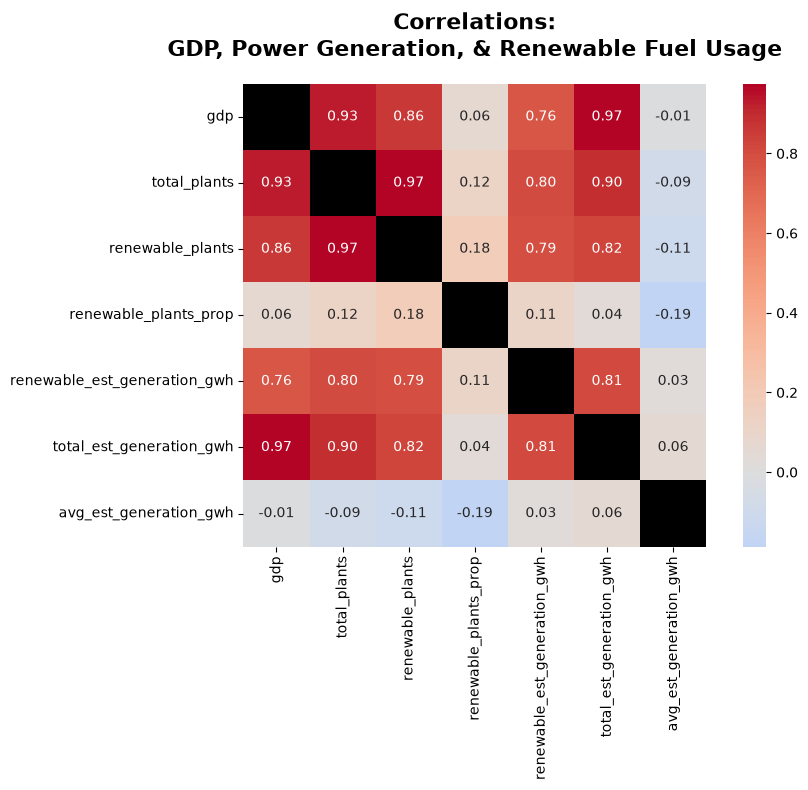

In [72]:
# Plot correlation as heatmap
# Remove diagonal from correlation matrix for plotand define mask
corr_table = corr_table.where(~np.eye(corr_table.shape[0], dtype=bool))
mask = corr_table.isna()

# Define figure setup
plt.figure(figsize=(10, 8))
# Update colormap to include black for diagonal
cmap = plt.cm.coolwarm.copy()
cmap.set_bad('black')

# Plot heatmap
sns.heatmap(
    corr_table,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    center=0,
    square=True
)

# Add title
plt.title('Correlations:\nGDP, Power Generation, & Renewable Fuel Usage', fontsize=16, fontweight='bold', pad=20)

# Save plot to outputs folder
plt.savefig(
    os.path.join(output_path, r'plots\Correlation heatmap.png'), # Path for saved plot
    dpi=150,   # Required resolution in assignemnt
    bbox_inches='tight'
)

# Present plot
plt.tight_layout()
plt.show()